# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Jaya Jaya Institut

# **Studi Kasus:** Jaya Jaya Institut

- Nama: Sandhika Hamzah
- Email: sanvinzah@gmail.com
- Id Dicoding: sandhika_hamzah_jvzn

## 1. Business Understanding
    



*   Konteks Bisnis:


    Jaya Jaya Institut adalah institusi pendidikan tinggi yang telah berdiri sejak tahun 2000. Meskipun memiliki reputasi yang sangat baik dan telah mencetak banyak lulusan, institusi ini menghadapi masalah internal yang cukup serius: **tingginya angka siswa yang tidak menyelesaikan pendidikan alias *dropout*.**
    
    



*   Problem Statement (Pernyataan Masalah):

    Tingkat *dropout* yang tinggi merugikan institusi secara finansial maupun reputasi, serta merugikan masa depan siswa itu sendiri. Manajemen seringkali terlambat menyadari bahwa seorang siswa akan melakukan *dropout* sehingga tidak ada tindakan preventif yang bisa dilakukan.
    
    



*   Goals (Tujuan Proyek):


    1.   Analisis Pola:Menganalisis data historis mahasiswa (akademik, demografi, dan status ekonomi) untuk menemukan faktor-faktor utama penyebab *dropout*.
    2.   Deteksi Dini (Machine Learning): Membangun model prediksi klasifikasi yang mampu mendeteksi mahasiswa berisiko *dropout* sedini mungkin sehingga institusi dapat memberikan bimbingan khusus atau intervensi.
    3.   Monitoring (Dashboard): Membuat sistem *dashboard* interaktif agar manajemen dapat memonitor performa dan status mahasiswa secara real-time.




## Persiapan

Pada tahap ini akan dilakukan pengimportan semua *library* (pustaka) bahasa pemrograman Python yang dibutuhkan untuk manipulasi data, visualisasi, dan pembangunan model *Machine Learning*.

### Menyiapkan library yang dibutuhkan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Library untuk Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
# Setup visualisasi
sns.set_theme(style='whitegrid')

### Menyiapkan data yang akan diguankan

Dilakukan pemuatan *dataset* yang diberikan oleh pihak Jaya Jaya Institut. Karena file berformat `.csv` dan dipisahkan oleh titik koma (`;`), maka atur parameter `sep=';'`.
  

In [ ]:
df = pd.read_csv('data (1).csv', sep=';')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

Tahap *Data Understanding* bertujuan untuk memahami karakteristik dari data yang dimiliki sebelum diolah lebih lanjut. Langkah yang dilakukan meliputi:

*   Memeriksa tipe data dari setiap kolom (Numerik atau Kategorik).
*   Mengecek keberadaan nilai yang hilang (*missing values*).
*   **Exploratory Data Analysis (EDA):** Melihat distribusi kolom target yaitu `Status` (apakah mahasiswa tersebut Dropout, Graduate, atau Enrolled).
*   Mencari korelasi awal, misalnya: apakah mahasiswa yang menunggak biaya kuliah (*Tuition fees up to date*) lebih berisiko *dropout*?





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

/tmp/ipykernel_3400/3781417942.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Status', palette='Set2')


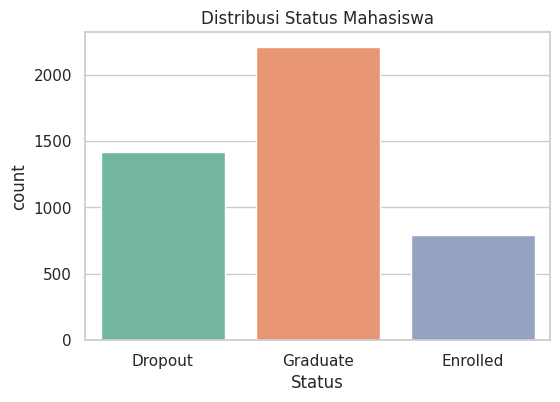

In [ ]:
# Mengecek informasi dasar mengenai jumlah kolom, baris, dan missing value
df.info()
# Melihat proporsi status mahasiswa
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Status', palette='Set2')
plt.title('Distribusi Status Mahasiswa')
plt.show()

## Data Preparation / Preprocessing

Data asli jarang sekali bisa langsung dimasukkan ke dalam model prediksi. Diperlukan persiapan data (*Data Preparation*). Tahapan yang dilakukan dalam sesi ini:\n",

1.   **Handling Missing Values:** Jika ada data kosong, dilakukan pembuangan atau pengisian dengan nilai median/modus.
2.   **Feature Engineering / Encoding:** Mesin hanya memahami angka. Fitur target `Status` berbentuk teks (Dropout, Graduate, Enrolled). Maka, diperlukan pengubahan menjadi angka. Karena fokusnya mendeteksi Dropout, maka bisa dilakukan klasifikasi *binary* (Dropout = 1, Lainnya = 0).
3.   **Scaling:** Menyamakan skala/rentang angka antar kolom agar algoritma bekerja lebih optimal dan stabil.



In [ ]:
# Filter data, misalnya hanya mengambil yang sudah pasti 'Dropout' atau 'Graduate' untuk training
df_clean = df[df['Status'].isin(['Dropout', 'Graduate'])].copy()
# Encoding Target Variable (1 untuk Dropout, 0 untuk Graduate)
df_clean['Status_Encoded'] = df_clean['Status'].apply(lambda x: 1 if x == 'Dropout' else 0)
# Memisahkan Feature (X) dan Target (y)
X = df_clean.drop(['Status', 'Status_Encoded'], axis=1)
y = df_clean['Status_Encoded']
# Feature Scaling (Standarisasi agar tidak ada fitur yang dominan karena perbedaan skala angka)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Modeling

Sekarang saatnya melatih model. Model yang akan dibangun bertujuan untuk mencari pola (berdasarkan nilai ujian, status beasiswa, tagihan, dsb.) yang menandakan siswa akan *dropout*.

*   Pertama membagi data menjadi dua: **Data Latih (Train)** untuk mengajar mesin, dan **Data Uji (Test)** untuk mengetes performa mesin.
*   Kedua gunakan model **Random Forest Classifier** karena kemampuannya menangani data tabular kompleks dan memberikan informasi mengenai *Feature Importance* (fitur apa yang paling memicu dropout).


    
    

In [ ]:
# Split data: 80% untuk Train, 20% untuk Test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
# Inisiasi Model Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
# Melatih model
model.fit(X_train, y_train)
# Melakukan prediksi pada data Test
y_pred = model.predict(X_test)

## Evaluation

Tahap ini adalah validasi apakah modelnya bekerja dengan baik.Bagi institusi seperti Jaya Jaya, metrik **Recall (Sensitivitas)** terhadap kelas Dropout sangatlah penting. Mengapa?
Karena *lebih baik model salah mengira siswa akan dropout padahal tidak (False Positive)*, daripada *model mengira siswa aman-aman saja padahal kenyataannya dia dropout (False Negative)*, karena tujuan utamanya adalah bimbingan preventif.

--- Laporan Klasifikasi ---
              precision    recall  f1-score   support

Graduate (0)       0.90      0.95      0.92       449
 Dropout (1)       0.92      0.82      0.87       277

    accuracy                           0.90       726
   macro avg       0.91      0.89      0.90       726
weighted avg       0.90      0.90      0.90       726

\n--- Confusion Matrix ---


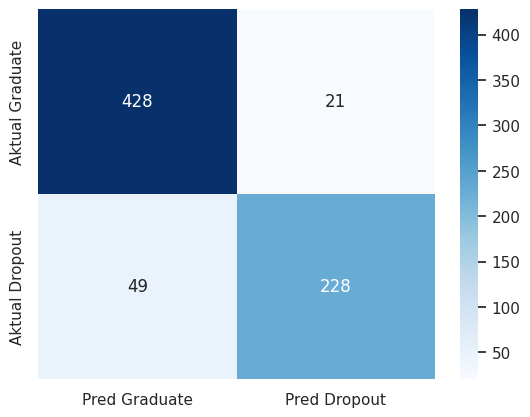

In [ ]:
print('--- Laporan Klasifikasi ---')
print(classification_report(y_test, y_pred, target_names=['Graduate (0)', 'Dropout (1)']))
print('\\n--- Confusion Matrix ---')
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred Graduate', 'Pred Dropout'], yticklabels=['Aktual Graduate', 'Aktual Dropout'])
plt.show()

In [ ]:
# Menyimpan model Random Forest
joblib.dump(model, 'rf_model.joblib')
print("Model berhasil disimpan sebagai 'rf_model.joblib'")

# Menyimpan objek scaler
joblib.dump(scaler, 'scaler.joblib')
print("Scaler berhasil disimpan sebagai 'scaler.joblib'")

Model berhasil disimpan sebagai 'rf_model.joblib'
Scaler berhasil disimpan sebagai 'scaler.joblib'
